# Customer Investment Needs — Modeling

**Goal:** Train binary classifiers for each investment target, build an entropy-gated soft-vote ensemble, and flag uncertain predictions for human review using KNN neighbourhood disagreement.

**Inputs:** `processed_features.xlsx` — output of `0-DataPreprocessing.ipynb`

**Outputs:** `model_predictions.xlsx` — per-customer probabilities, ensemble predictions, and review flags — consumed by `2_next_best_action_system_design.ipynb`

---

## Notebook Structure

1. Imports & Setup
2. Load Processed Data
3. Train / Test Split
4. Scaling
5. Distance Matrix Construction
6. Model Evaluation Strategy
7. Modeling
8. Entropy-Gated Ensemble
9. Recommendations
10. Export

---
## 1. Imports & Setup

In [9]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from plots import plot_feature_importance


import plots
import utilities
import models as model_module
from models import ModelFactory
from utilities import (
    display_results_table,
    display_tuning_results,
    plot_model_diagnostics,
    run_experiment,
    binary_entropy,
    split_by_entropy,
    evaluate_entropy_splits,
)

# Hot-reload during development
importlib.reload(plots)
importlib.reload(utilities)
importlib.reload(model_module)

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi":       110,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "text.color":       "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
})

SEED    = 42
TARGETS = ["IncomeInvestment", "AccumulationInvestment"]

---
## 2. Load Processed Data

Two sheets from `processed_features.xlsx`:
- `features` — engineered features
- `targets`  — two binary labels

In [10]:
input_path = "processed_features.xlsx"

feature_df = pd.read_excel(input_path, sheet_name="features", index_col=0)
targets_df = pd.read_excel(input_path, sheet_name="targets",  index_col=0)

print("features :", feature_df.shape)
print("targets  :", targets_df.shape)
print("\nClass balance:")
print(targets_df.mean().round(3))
feature_df.head()

features : (5000, 8)
targets  : (5000, 2)

Class balance:
IncomeInvestment          0.384
AccumulationInvestment    0.513
dtype: float64


,Age,FamilyMembers,FinancialEducation,RiskPropensity,Wealth_log,Income_log,IncomePerFamilyMember_log,Income_Wealth_Ratio_log
0,64,3,0.563402,0.582442,5.122047,5.048320,3.962466,0.656742
1,57,2,0.197647,0.396081,4.219891,4.228070,3.549398,0.697306
2,53,2,0.404948,0.407098,3.602428,3.398944,2.738659,0.593727
3,67,3,0.610428,0.332732,4.726979,4.620627,3.541516,0.640910
4,57,3,0.507142,0.501799,4.122068,4.141433,3.074125,0.703036


In [11]:
NUMERICAL_FEATURES   = feature_df.select_dtypes(include="number").columns.tolist()
CATEGORICAL_FEATURES = feature_df.select_dtypes(exclude="number").columns.tolist()

print("Numerical  :", NUMERICAL_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Numerical  : ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log']
Categorical: []


---
## 3. Train / Test Split

Stratified 80/20 split applied **once** before any scaling. Stratification preserves class balance in both splits.

> **Leakage note:** The scaler is fit exclusively on `X_train_*` (§4). Distance-matrix construction (§5) also uses only the training features so that test-set geometry does not influence any upstream step.

In [12]:
income_series = targets_df["IncomeInvestment"]
accum_series  = targets_df["AccumulationInvestment"]

X_train_inc, X_test_inc, y_income_train, y_income_test = train_test_split(
    feature_df, income_series,
    test_size=0.2, random_state=SEED, stratify=income_series,
)

X_train_acc, X_test_acc, y_accum_train, y_accum_test = train_test_split(
    feature_df, accum_series,
    test_size=0.2, random_state=SEED, stratify=accum_series,
)

print(f"Income       — train: {len(X_train_inc):,}  test: {len(X_test_inc):,}")
print(f"Accumulation — train: {len(X_train_acc):,}  test: {len(X_test_acc):,}")

Income       — train: 4,000  test: 1,000
Accumulation — train: 4,000  test: 1,000


---
## 4. Scaling

`StandardScaler` is **fit on the training set only** and then applied to both train and test. Fitting on the full dataset before the split would leak test statistics into training.

In [13]:
# 1. Scalers (separate per target)
scaler_inc = StandardScaler()
scaler_acc = StandardScaler()

# 2. Income scaling
X_train_inc_scaled = pd.DataFrame(
    scaler_inc.fit_transform(X_train_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_inc.index
)
X_test_inc_scaled = pd.DataFrame(
    scaler_inc.transform(X_test_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_inc.index
)
for col in CATEGORICAL_FEATURES:
    X_train_inc_scaled[col] = X_train_inc[col].values
    X_test_inc_scaled[col]  = X_test_inc[col].values

# 3. Accumulation scaling
X_train_acc_scaled = pd.DataFrame(
    scaler_acc.fit_transform(X_train_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_acc.index
)
X_test_acc_scaled = pd.DataFrame(
    scaler_acc.transform(X_test_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_acc.index
)
for col in CATEGORICAL_FEATURES:
    X_train_acc_scaled[col] = X_train_acc[col].values
    X_test_acc_scaled[col]  = X_test_acc[col].values

# 4. Sanity checks
print("Income train means (should be ~0):")
print(X_train_inc_scaled[NUMERICAL_FEATURES].mean().round(3))
print("\nAccumulation train means (should be ~0):")
print(X_train_acc_scaled[NUMERICAL_FEATURES].mean().round(3))

Income train means (should be ~0):
Age                         -0.0
FamilyMembers               -0.0
FinancialEducation          -0.0
RiskPropensity              -0.0
Wealth_log                   0.0
Income_log                   0.0
IncomePerFamilyMember_log   -0.0
Income_Wealth_Ratio_log     -0.0
dtype: float64

Accumulation train means (should be ~0):
Age                          0.0
FamilyMembers                0.0
FinancialEducation          -0.0
RiskPropensity              -0.0
Wealth_log                  -0.0
Income_log                  -0.0
IncomePerFamilyMember_log    0.0
Income_Wealth_Ratio_log     -0.0
dtype: float64


---
## 5. Distance Matrix Construction

Built on **training features only** — the test set must not influence the neighbourhood structure used later in the KNN uncertainty step.

> **Design note:** Feature scaling (§4) ensures no single variable dominates Euclidean distances. Later stages may add feature weights to reflect financial relevance (e.g. risk propensity, income).

In [14]:
distance_matrix = pairwise_distances(X_train_inc_scaled, metric="euclidean")

print(f"Distance matrix shape : {distance_matrix.shape}")
print(f"Value range           : [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean distance         : {distance_matrix.mean():.4f}")

assert np.allclose(np.diag(distance_matrix), 0, atol=1e-6), "Diagonal non-zero."
print("Diagonal check        : OK")

Distance matrix shape : (4000, 4000)
Value range           : [0.0000, 19.8986]
Mean distance         : 3.6979
Diagonal check        : OK


---
## 6. Model Evaluation Strategy

Binary labels: **Class 0** = not suitable, **Class 1** = suitable for a product. Because mis-recommending and missing relevant clients carry different costs, accuracy alone is insufficient. The framework uses three layered metrics:

| Metric | Type | Role |
|--------|------|------|
| Safety Constraint — Recall(class 0) ≥ 0.90 | Hard rule | Rejects models that pass too many bad recommendations |
| Safety-Constrained Precision | Hybrid | Primary selection metric — quality among safe models |
| Balanced Business Score | Soft | Comparison — coverage vs. precision trade-off |

**Why not accuracy?** It treats all errors equally, ignores class imbalance, and hides failures on the minority (but important) positive class.

---

## 7. Modeling

Each `run_experiment` executes a leakage-safe pipeline:

1. **Optional tuning** on `X_train` only
2. **Cross-validation on `X_train`** and single evaluation on `X_test`
3. **Final fit on full `X_train`** for inference
4. **Outputs:**
   - `y_prob_train`: used for analysis/ensemble design
   - `y_prob_test`: used for final evaluation
   - `y_pred_test`: final class predictions

This structure ensures clean separation between training, evaluation, and downstream ensemble usage.

### 7.1 Logistic Regression

A linear baseline classifier used as a calibration reference across both Income and Accumulation tasks. It performs well when relationships between features and the target are approximately linear. It is sensitive to feature scaling (handled in preprocessing) and serves as an interpretable benchmark for the ensemble.

---

### 7.2 XGBoost

A gradient-boosted tree model and the strongest nonlinear learner in this system. It captures complex feature interactions and nonlinear decision boundaries effectively. It is typically the best standalone performer on tabular data and a key contributor to ensemble performance.

---

### 7.3 K-Nearest Neighbors (KNN)

A distance-based model that relies heavily on feature scaling and local similarity structure. It performs well in locally smooth regions of the feature space but can degrade in high-dimensional or noisy settings. Its contribution is most useful in capturing local patterns missed by global models like XGBoost.

---

### 7.4 Support Vector Machine (SVM)

A margin-based classifier that finds an optimal separating hyperplane between classes. Its performance depends strongly on kernel choice and hyperparameter tuning. It is effective in medium-dimensional spaces but sensitive to scaling and data distribution shifts.

---

### 7.5 Gaussian Naive Bayes

A probabilistic generative model assuming conditional independence between features. Despite its simplicity, it provides a fast and stable baseline and can perform well in noisy regimes. However, it cannot capture complex feature interactions compared to ensemble methods.


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.6327       |
|  Best Params  |      C: 0.01       |
|               |    penalty: l2     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.763  | 0.014  |     0.783     |
| Precision (0/1) |  0.758  | 0.021  | 0.781 / 0.789 |
|  Recall (0/1)   |  0.729  | 0.147  | 0.901 / 0.594 |
|    F1 (0/1)     |  0.737  | 0.085  | 0.836 / 0.678 |
|     Safety      |  -1.0   |  0.0   |     0.789     |
|    Balanced     |  0.632  | 0.024  |     0.652     |
+-----------------+---------+--------+---------------+


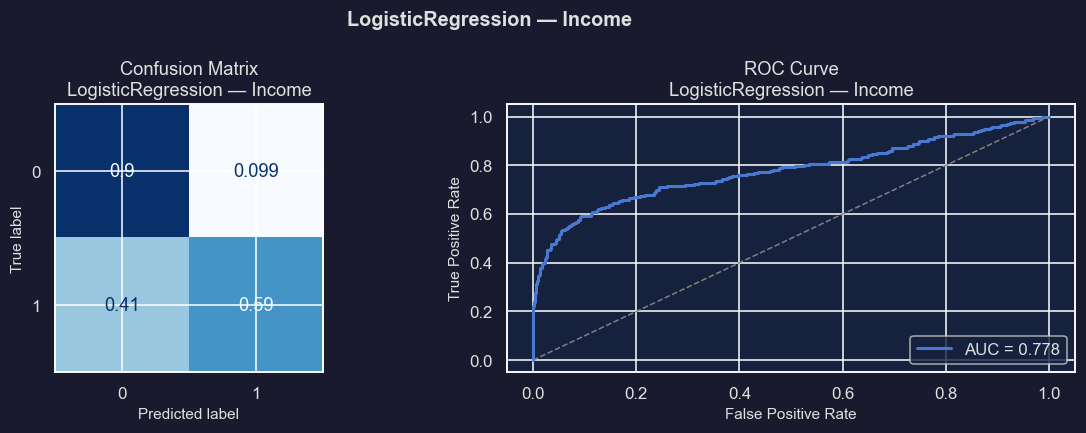


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.6995       |
|  Best Params  |       C: 10        |
|               |    penalty: l1     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.658  | 0.019  |     0.67      |
| Precision (0/1) |  0.659  | 0.021  | 0.673 / 0.668 |
|  Recall (0/1)   |  0.657  | 0.061  | 0.628 / 0.710 |
|    F1 (0/1)     |  0.656  | 0.033  | 0.650 / 0.688 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.695  | 0.017  |     0.697     |
+-----------------+---------+--------+---------------+


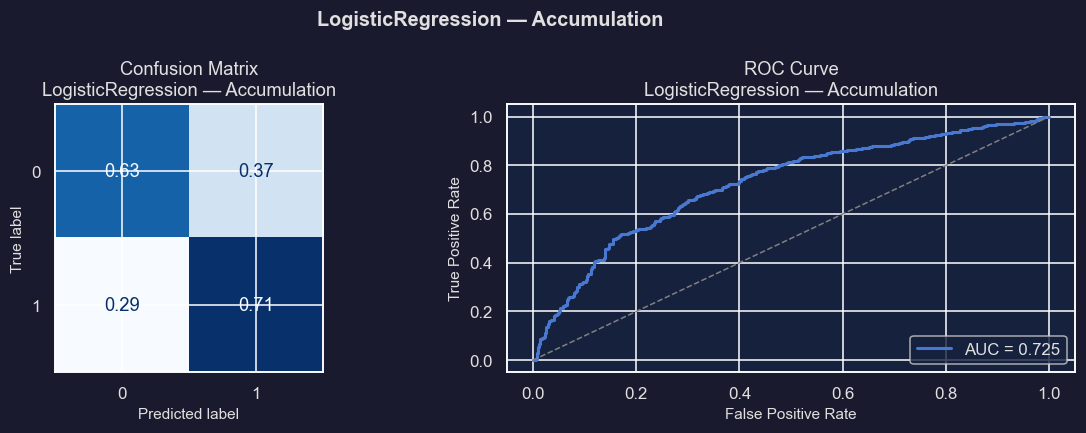


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.6872                |
|  Best Params  | colsample_bytree: 0.9450489982907728 |
|               |       gamma: 4.753209918822569       |
|               |  learning_rate: 0.18873004853482075  |
|               |             max_depth: 4             |
|               |         min_child_weight: 1          |
|               |          n_estimators: 314           |
|               |    reg_alpha: 0.15491713224563722    |
|               |   reg_lambda: 0.18488177854678023    |
|               |    subsample: 0.9699449534934814     |
+---------------+--------------------------------------+

XGBoost — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+

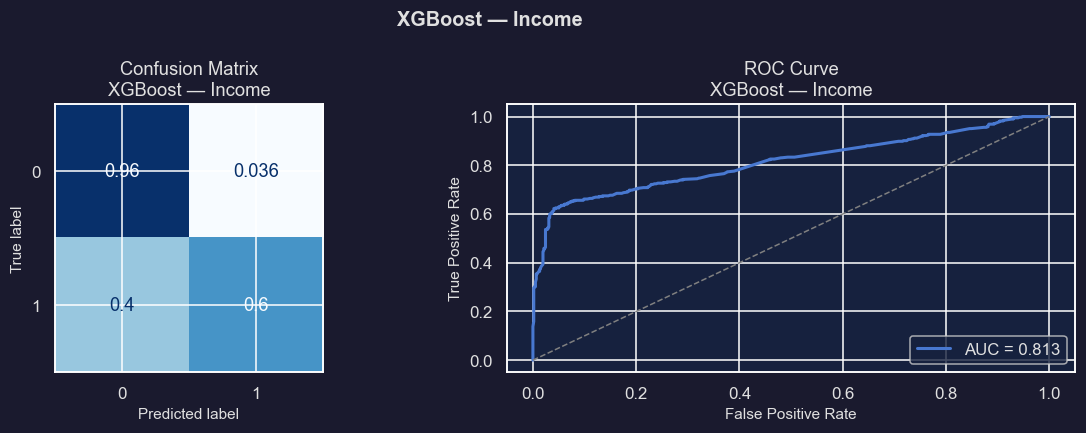


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.8023                |
|  Best Params  | colsample_bytree: 0.9061979941786817 |
|               |      gamma: 0.8593578069828035       |
|               | learning_rate: 0.059989768591227254  |
|               |             max_depth: 5             |
|               |         min_child_weight: 6          |
|               |          n_estimators: 138           |
|               |    reg_alpha: 3.7790026641794077     |
|               |    reg_lambda: 5.562380663209308     |
|               |    subsample: 0.9559644307534418     |
+---------------+--------------------------------------+

XGBoost — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set 

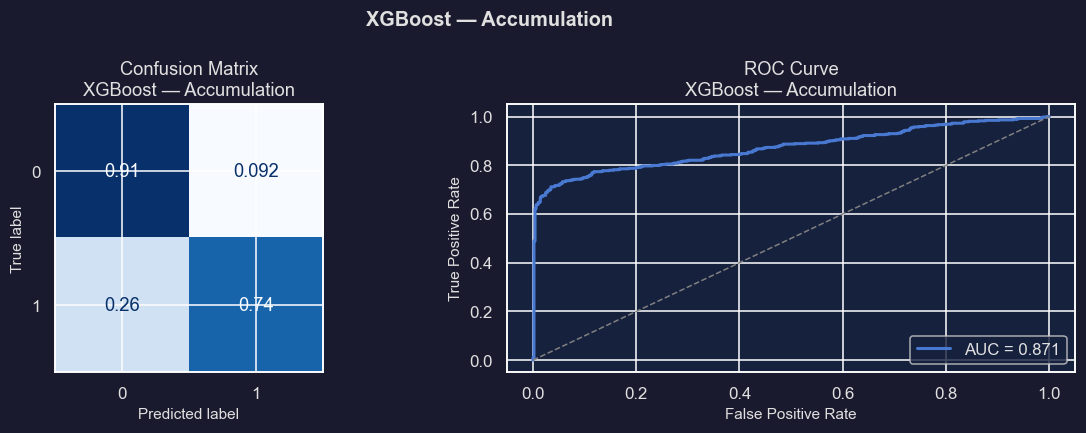


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |       0.622       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 31  |
|               | weights: distance |
+---------------+-------------------+

KNN — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.774  | 0.011  |     0.792     |
| Precision (0/1) |  0.789  | 0.031  | 0.773 / 0.846 |
|  Recall (0/1)   |  0.728  |  0.2   | 0.937 / 0.560 |
|    F1 (0/1)     |  0.739  | 0.098  | 0.847 / 0.674 |
|     Safety      |  0.818  | 0.011  |     0.846     |
|    Balanced     |  0.616  | 0.022  |     0.646     |
+-----------------+---------+--------+---------------+


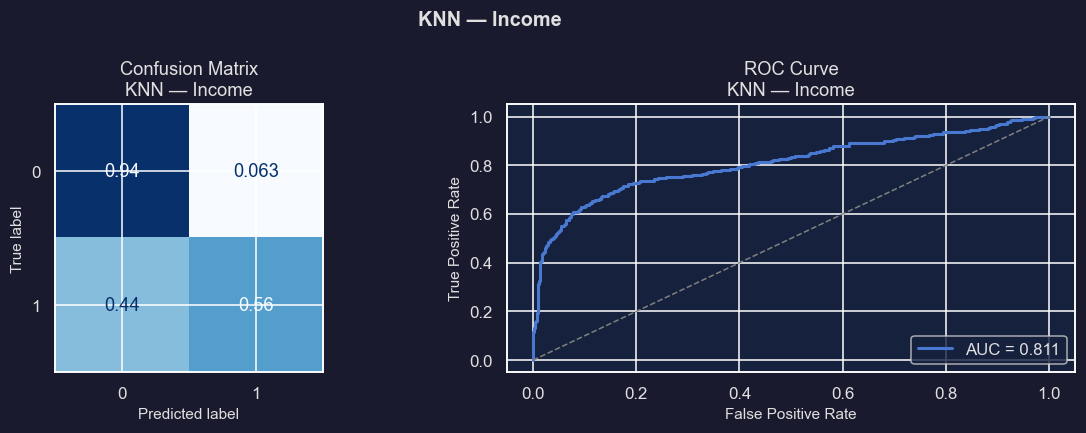


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |      0.7505       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 36  |
|               | weights: distance |
+---------------+-------------------+

KNN — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.762  | 0.014  |     0.768     |
| Precision (0/1) |  0.764  | 0.031  | 0.733 / 0.810 |
|  Recall (0/1)   |  0.763  | 0.038  | 0.823 / 0.715 |
|    F1 (0/1)     |  0.762  | 0.014  | 0.776 / 0.760 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.748  | 0.014  |     0.744     |
+-----------------+---------+--------+---------------+


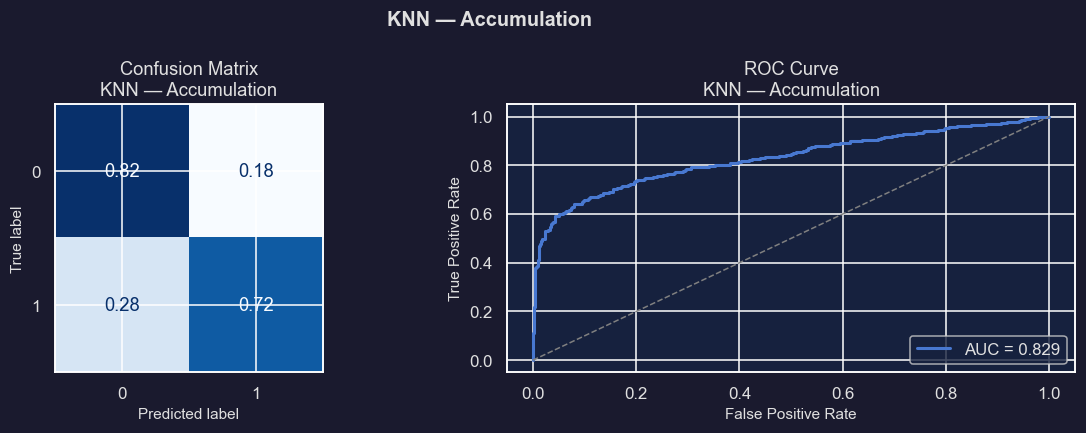


✔ Completed all experiments

Models trained:
 - logistic_income
 - logistic_accum
 - xgb_income
 - xgb_accum
 - knn_income
 - knn_accum

Income models: ['logistic', 'xgb', 'knn']
Accum models: ['logistic', 'xgb', 'knn']


In [16]:
import numpy as np

# 1. MODEL REGISTRY (ADD / REMOVE MODELS HERE)
MODEL_LIST = [
              "logistic",
              "xgb",
              "knn",
#              "svm",
#              "gnb"
]

# 2. STORAGE
model_outputs_income = []
model_outputs_accum = []

# 3. RUN ALL EXPERIMENTS

trained_models = {}

for model_name in MODEL_LIST:

    # =========================
    # INCOME
    # =========================
    inc_model, inc_results, inc_train_prob, inc_test_prob, inc_preds = run_experiment(
        model_name, "Income",
        X_train_inc_scaled, y_income_train,
        X_test_inc_scaled, y_income_test,
        tune=True
    )

    # =========================
    # ACCUMULATION
    # =========================
    acc_model, acc_results, acc_train_prob, acc_test_prob, acc_preds = run_experiment(
        model_name, "Accumulation",
        X_train_acc_scaled, y_accum_train,
        X_test_acc_scaled, y_accum_test,
        tune=True
    )

    # ========================================================
    # STORE MODELS
    # ========================================================
    trained_models[f"{model_name}_income"] = inc_model
    trained_models[f"{model_name}_accum"] = acc_model

    # ========================================================
    # BUILD CLEAN STRUCTURES (FOR ENSEMBLING)
    # ========================================================

    model_outputs_income.append({
        "name": model_name,
        "train_prob": np.asarray(inc_train_prob),
        "test_prob": np.asarray(inc_test_prob),
        "y_train": y_income_train.values,
        "y_test": y_income_test.values,
    })

    model_outputs_accum.append({
        "name": model_name,
        "train_prob": np.asarray(acc_train_prob),
        "test_prob": np.asarray(acc_test_prob),
        "y_train": y_accum_train.values,
        "y_test": y_accum_test.values,
    })


# ============================================================
# 4. FINAL OUTPUT STRUCTURE
# ============================================================

print("\n✔ Completed all experiments")

print("\nModels trained:")
for k in trained_models:
    print(" -", k)

print("\nIncome models:", [m["name"] for m in model_outputs_income])
print("Accum models:", [m["name"] for m in model_outputs_accum])

#### Feature Importance

Visualise which features drive each model's predictions.


--- Income Model: xgb ---


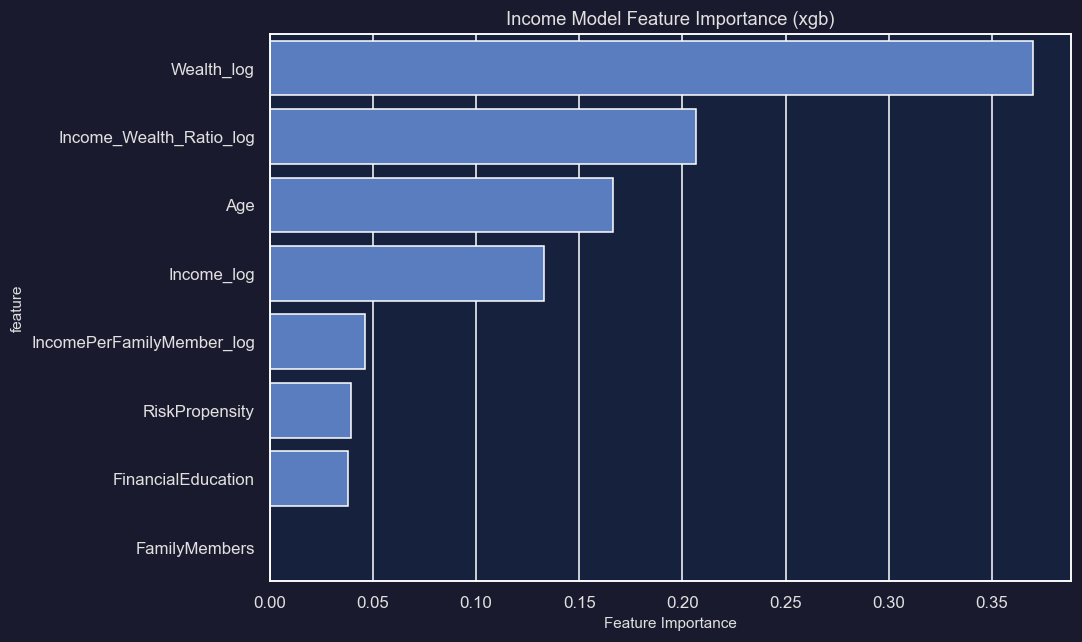


--- Accumulation Model: xgb ---


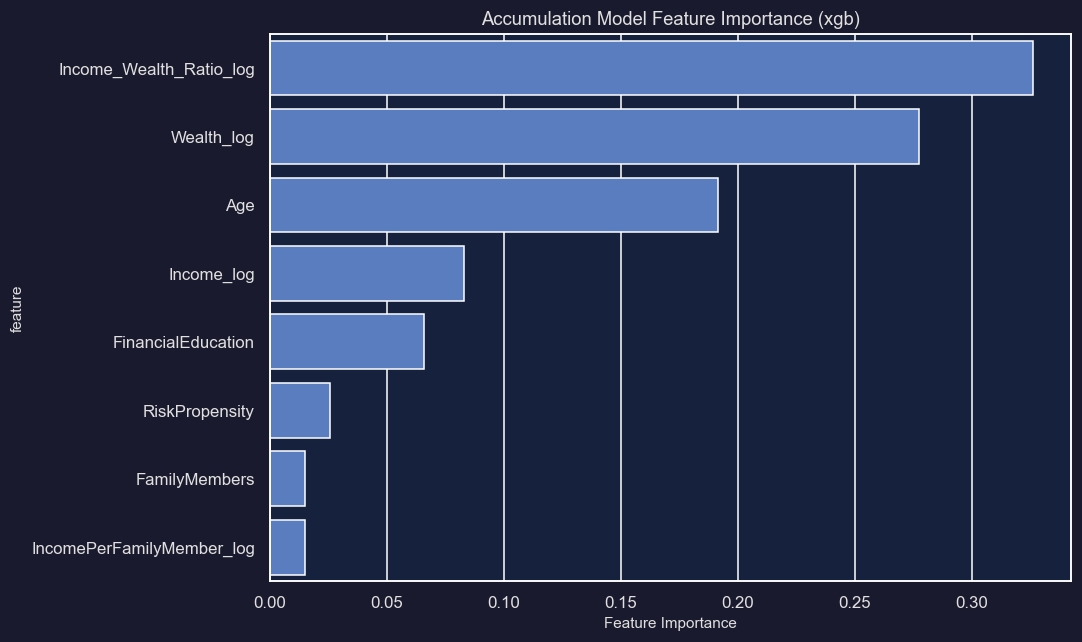

In [21]:
MODEL_LIST_feature_importance = ["xgb"]
# ============================================================
# 2. FEATURE IMPORTANCE PLOTTING (INCOME)
# ============================================================

for model_name in MODEL_LIST_feature_importance:
    key = f"{model_name}_income"
    model = trained_models[key]
    print(f"\n--- Income Model: {model_name} ---")
    plot_feature_importance(model,X_train_inc_scaled.columns,f"Income Model Feature Importance ({model_name})")


# ============================================================
# 3. FEATURE IMPORTANCE PLOTTING (ACCUMULATION)
# ============================================================

for model_name in MODEL_LIST_feature_importance:

    key = f"{model_name}_accum"
    model = trained_models[key]

    print(f"\n--- Accumulation Model: {model_name} ---")

    plot_feature_importance(
        model,
        X_train_acc_scaled.columns,
        f"Accumulation Model Feature Importance ({model_name})"
    )

#### Entropy Diagnostics

Entropy $H = -p\log_2 p - (1-p)\log_2(1-p)$ measures model uncertainty. Two uses:

- **Training set** — identify the top 5% noisiest samples for future active-learning relabelling.
- **Test set** — regulatory diagnostic: confident predictions should be far more accurate than uncertain ones, proving the model knows its own limits.

In [22]:
income_entropy_splits = {}
accum_entropy_splits = {}

for model_name in MODEL_LIST:

    # ============================================================
    # INCOME
    # ============================================================

    inc_model = trained_models[f"{model_name}_income"]

    inc_train_proba = inc_model.predict_proba(X_train_inc_scaled)[:, 1]

    clean_inc, review_inc, thr_inc = split_by_entropy(
        X_train_inc_scaled,
        y_income_train,
        inc_train_proba,
        top_percent=0.05,
    )

    income_entropy_splits[model_name] = {
        "clean": clean_inc,
        "review": review_inc,
        "threshold": thr_inc
    }

    # ============================================================
    # ACCUMULATION
    # ============================================================

    acc_model = trained_models[f"{model_name}_accum"]

    acc_train_proba = acc_model.predict_proba(X_train_acc_scaled)[:, 1]

    clean_acc, review_acc, thr_acc = split_by_entropy(
        X_train_acc_scaled,
        y_accum_train,
        acc_train_proba,
        top_percent=0.05,
    )

    accum_entropy_splits[model_name] = {
        "clean": clean_acc,
        "review": review_acc,
        "threshold": thr_acc
    }

    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    print(f"\n[{model_name.upper()}]")

    print(f"Income       — clean: {len(clean_inc):,}  review: {len(review_inc):,}")
    print(f"Accumulation — clean: {len(clean_acc):,}  review: {len(review_acc):,}")


[LOGISTIC]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[XGB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[KNN]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200



[LOGISTIC]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


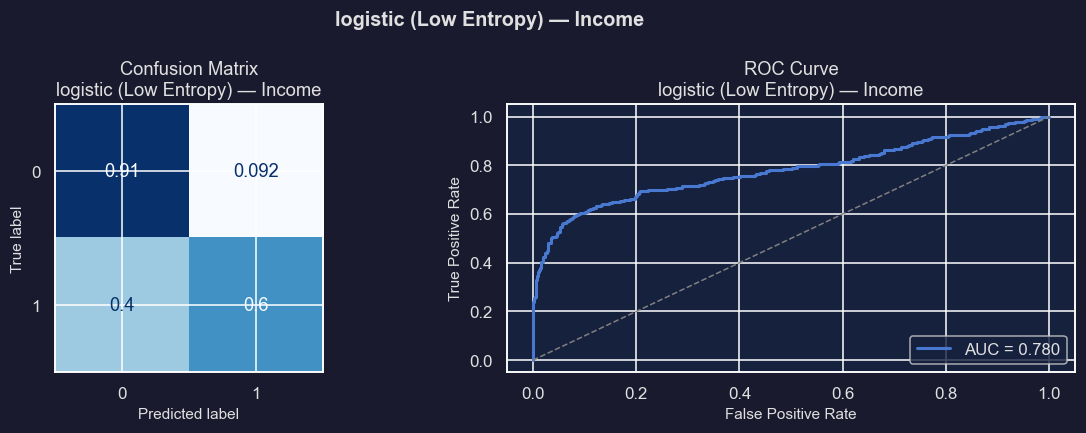


logistic (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.792   |
| Precision (0/1) |   nan   |  nan   |  0.793   |
|  Recall (0/1)   |   nan   |  nan   |  0.792   |
|    F1 (0/1)     |   nan   |  nan   |  0.784   |
|     Safety      |   nan   |  nan   |  0.802   |
|    Balanced     |   nan   |  nan   |  0.663   |
+-----------------+---------+--------+----------+


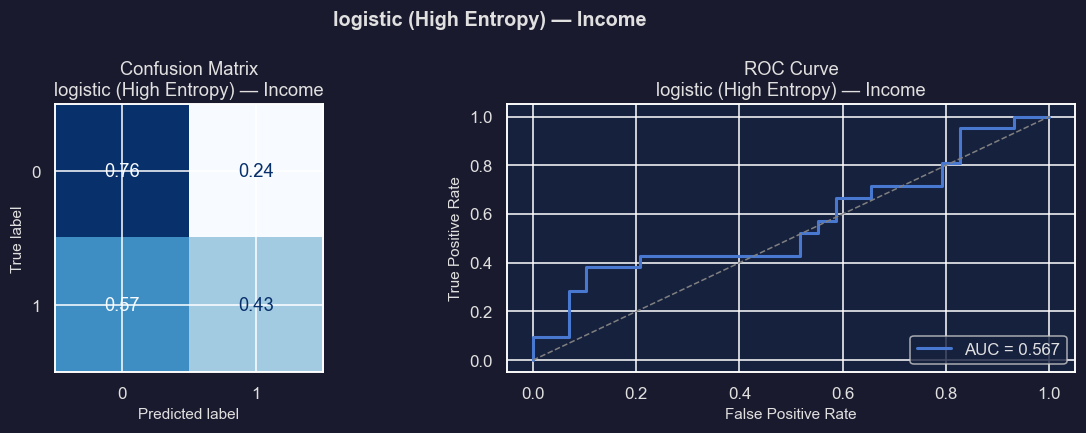


logistic (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.62   |
| Precision (0/1) |   nan   |  nan   |  0.612   |
|  Recall (0/1)   |   nan   |  nan   |   0.62   |
|    F1 (0/1)     |   nan   |  nan   |  0.609   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.469   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


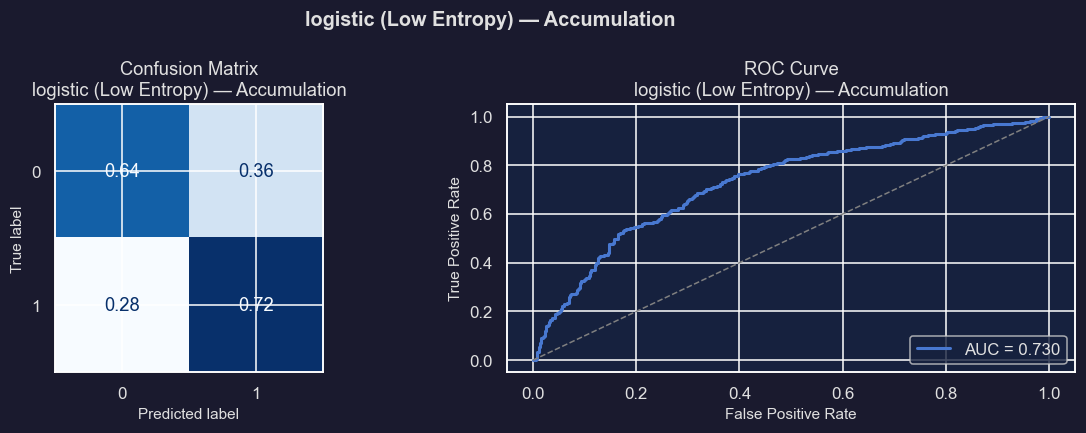


logistic (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.681   |
| Precision (0/1) |   nan   |  nan   |  0.681   |
|  Recall (0/1)   |   nan   |  nan   |  0.681   |
|    F1 (0/1)     |   nan   |  nan   |   0.68   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.709   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


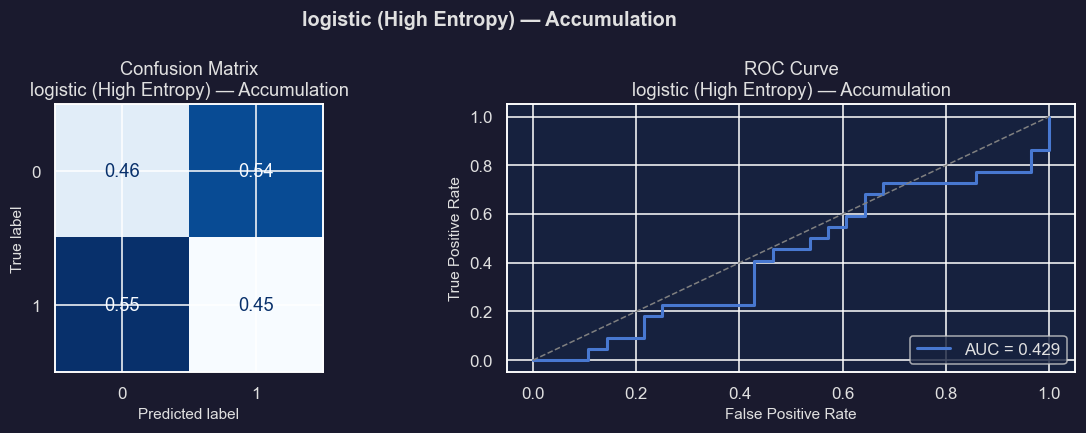


logistic (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.46   |
| Precision (0/1) |   nan   |  nan   |  0.467   |
|  Recall (0/1)   |   nan   |  nan   |   0.46   |
|    F1 (0/1)     |   nan   |  nan   |  0.462   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.438   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[XGB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


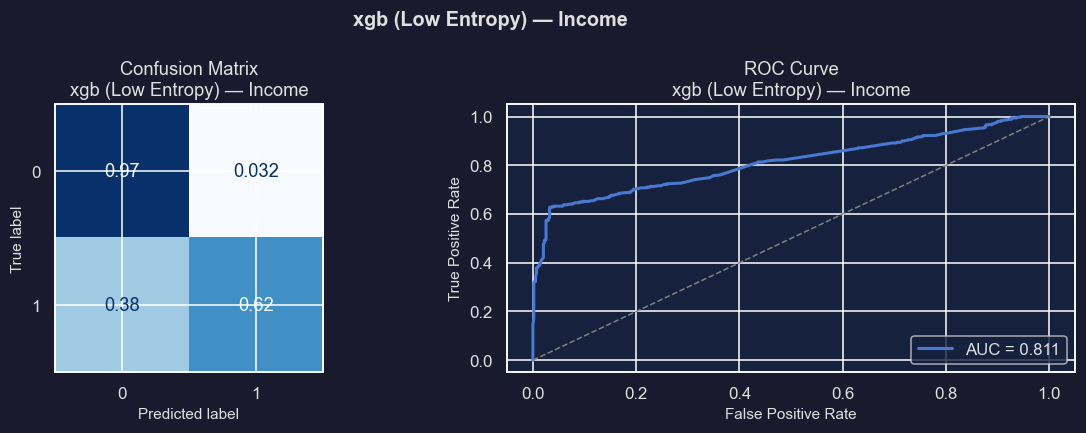


xgb (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.838   |
| Precision (0/1) |   nan   |  nan   |  0.852   |
|  Recall (0/1)   |   nan   |  nan   |  0.838   |
|    F1 (0/1)     |   nan   |  nan   |  0.829   |
|     Safety      |   nan   |  nan   |  0.922   |
|    Balanced     |   nan   |  nan   |  0.713   |
+-----------------+---------+--------+----------+


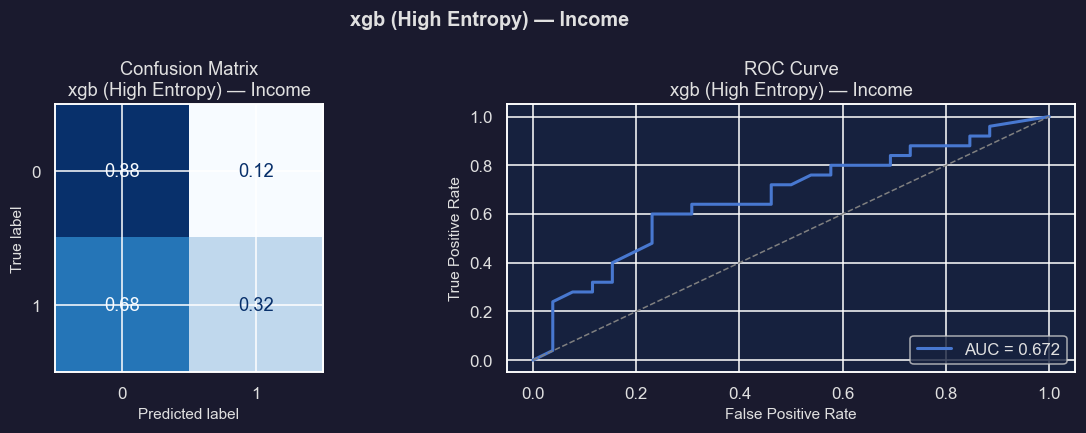


xgb (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.608   |
| Precision (0/1) |   nan   |  nan   |   0.65   |
|  Recall (0/1)   |   nan   |  nan   |  0.608   |
|    F1 (0/1)     |   nan   |  nan   |  0.573   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.442   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


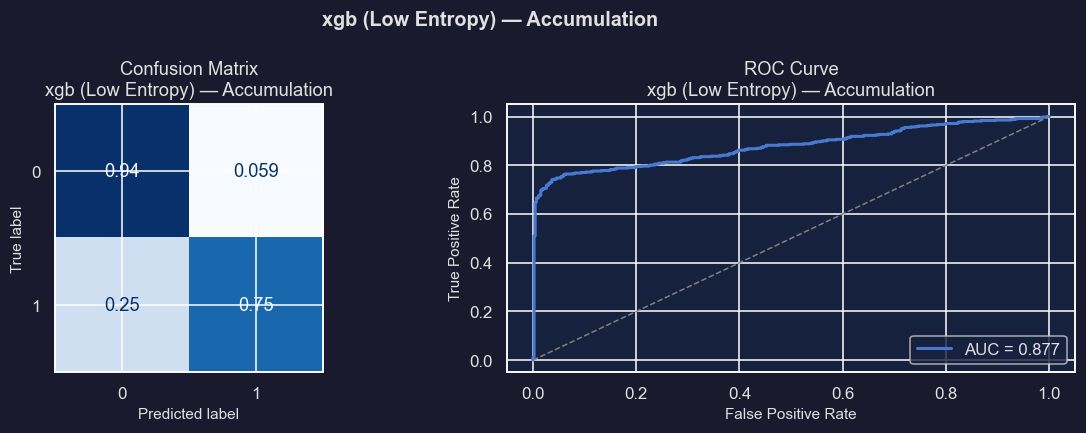


xgb (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.844   |
| Precision (0/1) |   nan   |  nan   |  0.859   |
|  Recall (0/1)   |   nan   |  nan   |  0.844   |
|    F1 (0/1)     |   nan   |  nan   |  0.843   |
|     Safety      |   nan   |  nan   |  0.932   |
|    Balanced     |   nan   |  nan   |  0.807   |
+-----------------+---------+--------+----------+


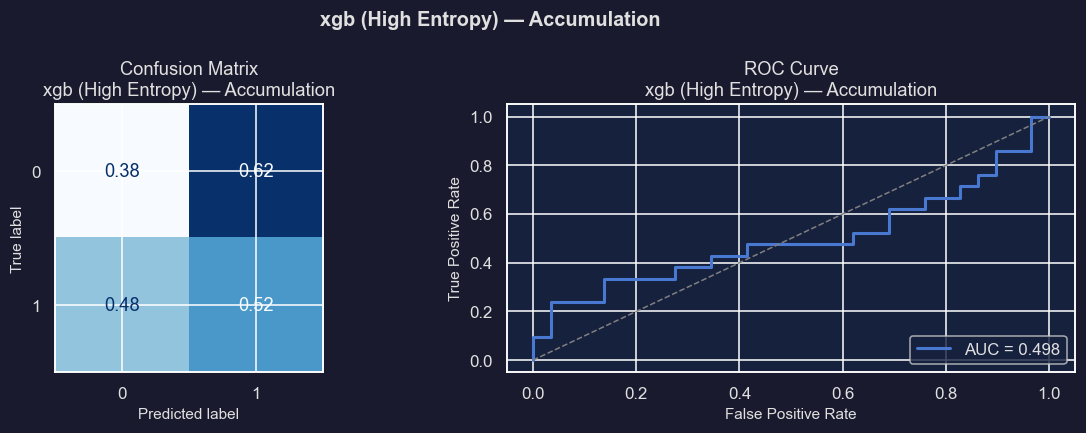


xgb (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.44   |
| Precision (0/1) |   nan   |  nan   |  0.463   |
|  Recall (0/1)   |   nan   |  nan   |   0.44   |
|    F1 (0/1)     |   nan   |  nan   |   0.44   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |   0.48   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[KNN]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


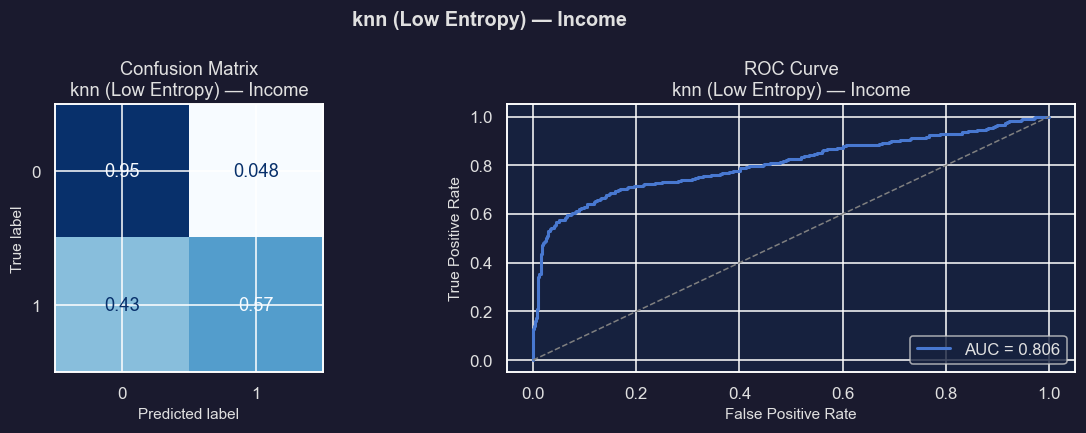


knn (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.808   |
| Precision (0/1) |   nan   |  nan   |  0.819   |
|  Recall (0/1)   |   nan   |  nan   |  0.808   |
|    F1 (0/1)     |   nan   |  nan   |  0.797   |
|     Safety      |   nan   |  nan   |  0.873   |
|    Balanced     |   nan   |  nan   |  0.658   |
+-----------------+---------+--------+----------+


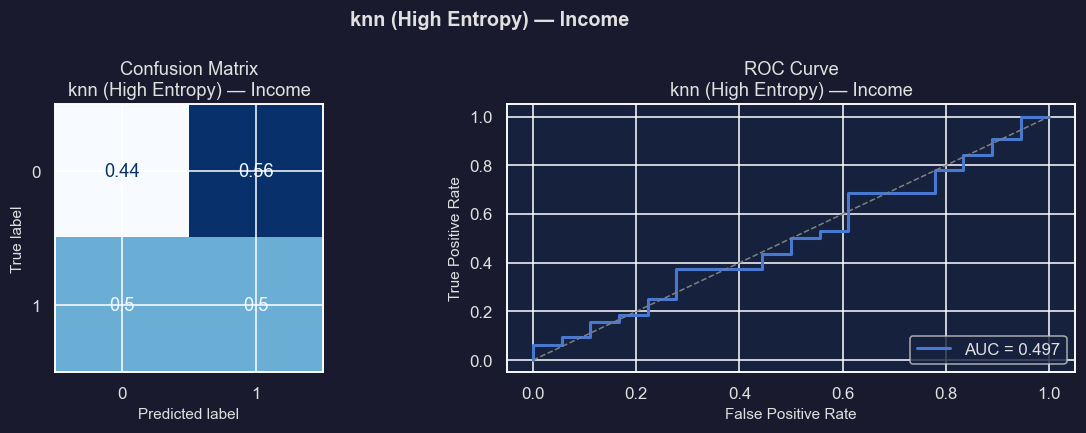


knn (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.48   |
| Precision (0/1) |   nan   |  nan   |  0.514   |
|  Recall (0/1)   |   nan   |  nan   |   0.48   |
|    F1 (0/1)     |   nan   |  nan   |   0.49   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.535   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


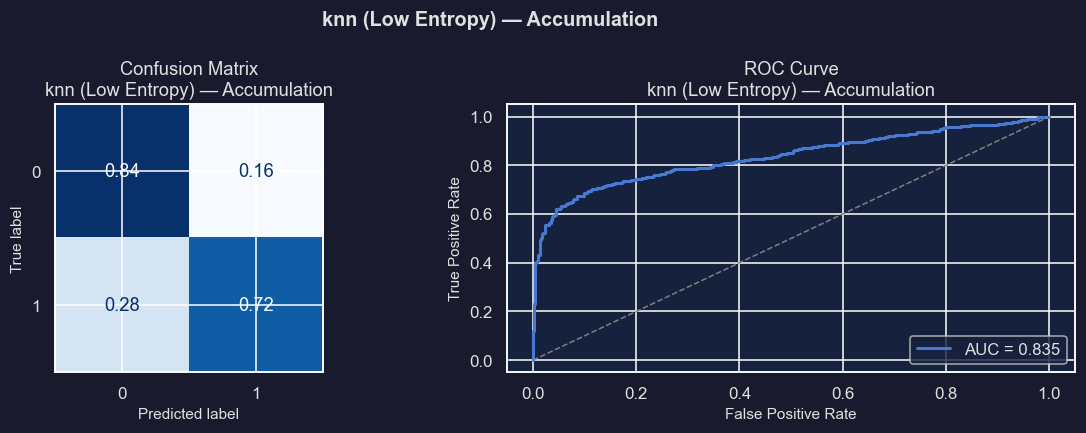


knn (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.782   |
| Precision (0/1) |   nan   |  nan   |  0.788   |
|  Recall (0/1)   |   nan   |  nan   |  0.782   |
|    F1 (0/1)     |   nan   |  nan   |  0.782   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.756   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


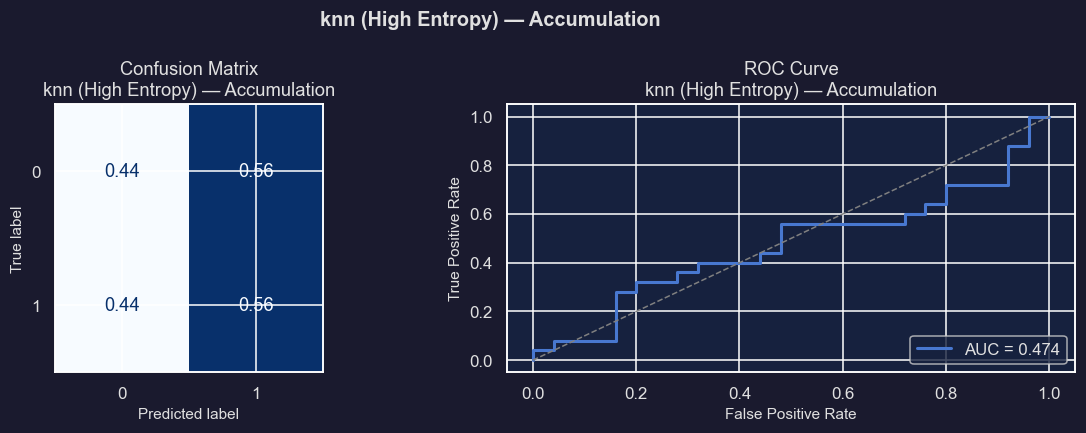


knn (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.5    |
| Precision (0/1) |   nan   |  nan   |   0.5    |
|  Recall (0/1)   |   nan   |  nan   |   0.5    |
|    F1 (0/1)     |   nan   |  nan   |  0.498   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.542   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


In [24]:
# ============================================================
# STORAGE
# ============================================================

entropy_train_splits = {
    "income": {},
    "accum": {},
}
entropy_test_results = {
    "income": {},
    "accum": {},
}

for model_name in MODEL_LIST:

    inc_model = trained_models[f"{model_name}_income"]
    acc_model = trained_models[f"{model_name}_accum"]

    # ============================================================
    # ENTROPY SPLIT ON TRAIN
    # ============================================================

    clean_income_train, review_income_train, thr_income_train = split_by_entropy(
        X_train_inc_scaled, y_income_train,
        inc_model.predict_proba(X_train_inc_scaled)[:, 1],
        top_percent=0.05,
    )
    clean_accum_train, review_accum_train, thr_accum_train = split_by_entropy(
        X_train_acc_scaled, y_accum_train,
        acc_model.predict_proba(X_train_acc_scaled)[:, 1],
        top_percent=0.05,
    )

    entropy_train_splits["income"][model_name] = {
        "clean":     clean_income_train,
        "review":    review_income_train,
        "threshold": thr_income_train,
    }
    entropy_train_splits["accum"][model_name] = {
        "clean":     clean_accum_train,
        "review":    review_accum_train,
        "threshold": thr_accum_train,
    }

    print(f"\n[{model_name.upper()}]")
    print(f"Income       — clean: {len(clean_income_train):,}  review: {len(review_income_train):,}")
    print(f"Accumulation — clean: {len(clean_accum_train):,}  review: {len(review_accum_train):,}")

    # ============================================================
    # ENTROPY DIAGNOSTICS ON TEST
    # ============================================================

    inc_test_prob = inc_model.predict_proba(X_test_inc_scaled)[:, 1]
    inc_test_pred = (inc_test_prob >= 0.5).astype(int)

    acc_test_prob = acc_model.predict_proba(X_test_acc_scaled)[:, 1]
    acc_test_pred = (acc_test_prob >= 0.5).astype(int)

    inc_test_diagnostics = evaluate_entropy_splits(
        inc_model, X_test_inc_scaled, y_income_test, inc_test_pred, inc_test_prob,
        model_name, "Income", alpha=0.05,
    )
    acc_test_diagnostics = evaluate_entropy_splits(
        acc_model, X_test_acc_scaled, y_accum_test, acc_test_pred, acc_test_prob,
        model_name, "Accumulation", alpha=0.05,
    )

    entropy_test_results["income"][model_name] = {
        "prob":        inc_test_prob,
        "pred":        inc_test_pred,
        "diagnostics": inc_test_diagnostics,
    }
    entropy_test_results["accum"][model_name] = {
        "prob":        acc_test_prob,
        "pred":        acc_test_pred,
        "diagnostics": acc_test_diagnostics,
    }

### Summary of Results

The analysis shows that XGBoost is the strongest performing model overall, but all models degrade significantly under high-entropy conditions, especially with respect to safety constraints.

#### Key Findings

- **XGBoost is the Best Performer**
  - Outperforms Logistic Regression and KNN on both tasks.
  - Achieves highest accuracy on Low Entropy datasets:
    - Income: 0.838
    - Accumulation: 0.844
  - Is the only model that passes the safety constraint on both Low Entropy tasks.

- **High Entropy Severely Degrades Performance**
  - All models experience a major drop in accuracy when moving from Low Entropy to High Entropy data.
  - Accuracy often falls into the ~40–60% range, close to random guessing for binary classification.

- **Universal Safety Failures on High Entropy**
  - Every model fails the safety constraint (Safety = -1.0) on High Entropy datasets.
  - This indicates that high-entropy data is currently unsafe for all tested configurations.

- **Accumulation Target is More Difficult**
  - Income prediction performs relatively well under Low Entropy across models.
  - Accumulation is harder:
    - Logistic Regression and KNN fail the safety constraint even under Low Entropy.
    - Only XGBoost successfully meets both performance and safety requirements for Accumulation.

#### Overall Conclusion
XGBoost is the only consistently reliable model, especially under low-entropy conditions. However, none of the models are robust or safe under high-entropy data, indicating a fundamental limitation in handling more complex or noisy distributions.



## 8. Entropy-Gated Ensemble

Instead of standard soft-voting (equal weights across models), we construct an
**uncertainty-aware ensemble** where each model’s contribution is scaled by its
inverse predictive entropy.

This ensures:
- confident predictions (low entropy) dominate
- uncertain predictions are down-weighted
- ambiguous cases are naturally escalated to review

---

### Mathematical formulation

For each model \( m \) with predicted probability \( p_m(x) \), the ensemble is:

$$
\hat{p}_{ensemble}(x)
=
\frac{\sum_{m} w_m(x)\, p_m(x)}{\sum_{m} w_m(x)}
$$

where the weight is defined as:

$$
w_m(x) = 1 - H(p_m(x))
$$

---

### Binary entropy definition

The binary entropy function used to measure uncertainty is:

$$
H(p) = -p \log_2(p) - (1 - p)\log_2(1 - p)
$$

---

### Interpretation

- When \( p \approx 0 \) or \( p \approx 1 \):
$$
H(p) \approx 0 \quad \Rightarrow \quad w \approx 1
$$

- When \( p \approx 0.5 \):
$$
H(p) \approx 1 \quad \Rightarrow \quad w \approx 0
$$

---

### Practical effect

This formulation turns the ensemble into a **confidence-weighted system** where:
- reliable models dominate predictions
- uncertain predictions are suppressed
- borderline cases are automatically flagged for review

In [25]:
# ============================================================
# 0. IMPORTANT ASSUMPTION
# ============================================================
# Train probabilities come from predictions on X_train ONLY.
# They are used ONLY to compute model reliability (NOT evaluation).

# ============================================================
# 1. HELPER
# ============================================================

def binary_entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

# ============================================================
# 2. MODEL RELIABILITY FROM TRAIN SIGNALS (ENTROPY)
# ============================================================

for inc, acc in zip(model_outputs_income, model_outputs_accum):
    assert inc["name"] == acc["name"], "Model order mismatch between income and accum lists"

    inc["weight"] = 1.0 - binary_entropy(inc["train_prob"])
    acc["weight"] = 1.0 - binary_entropy(acc["train_prob"])

    print(
        f"{inc['name']:10s} | "
        f"income weight: {inc['weight'].mean():.3f} | "
        f"accum weight:  {acc['weight'].mean():.3f}"
    )

# ============================================================
# 3. SCALAR MODEL WEIGHTS (GLOBAL RELIABILITY SCORES)
# ============================================================

income_model_weights = np.array([m["weight"].mean() for m in model_outputs_income])
accum_model_weights  = np.array([m["weight"].mean() for m in model_outputs_accum])

income_model_weights = income_model_weights / income_model_weights.sum()
accum_model_weights  = accum_model_weights  / accum_model_weights.sum()

for i, (inc, acc) in enumerate(zip(model_outputs_income, model_outputs_accum)):
    inc["w"] = income_model_weights[i]
    acc["w"] = accum_model_weights[i]

print("\nNormalized model weights:")
for inc, acc in zip(model_outputs_income, model_outputs_accum):
    print(f"  {inc['name']:10s} | income: {inc['w']:.3f} | accum: {acc['w']:.3f}")

# ============================================================
# 4. ENSEMBLE FUNCTION (TEST SET INFERENCE ONLY)
# ============================================================

def weighted_ensemble(model_outputs, prob_key="test_prob", weight_key="w"):
    probs   = np.vstack([m[prob_key]   for m in model_outputs])
    weights = np.array( [m[weight_key] for m in model_outputs])
    return np.average(probs, axis=0, weights=weights)

# ============================================================
# 5. FINAL ENSEMBLE (APPLIED ON TEST SET)
# ============================================================

ensemble_income_prob = weighted_ensemble(model_outputs_income)
ensemble_accum_prob  = weighted_ensemble(model_outputs_accum)

# ============================================================
# 6. SAFETY CHECKS
# ============================================================

assert len(ensemble_income_prob) == len(X_test_inc_scaled), "Income ensemble length mismatch"
assert len(ensemble_accum_prob)  == len(X_test_acc_scaled), "Accum ensemble length mismatch"

assert np.all((ensemble_income_prob >= 0) & (ensemble_income_prob <= 1)), "Income probs out of [0,1]"
assert np.all((ensemble_accum_prob  >= 0) & (ensemble_accum_prob  <= 1)), "Accum probs out of [0,1]"

print("\nEnsemble statistics:")
print(f"  Income — mean: {ensemble_income_prob.mean():.3f}  std: {ensemble_income_prob.std():.3f}")
print(f"  Accum  — mean: {ensemble_accum_prob.mean():.3f}  std: {ensemble_accum_prob.std():.3f}")

print("\n✓ Ensemble built from TRAIN reliability signals, evaluated on TEST set.")

logistic   | income weight: 0.416 | accum weight:  0.373
xgb        | income weight: 0.519 | accum weight:  0.580
knn        | income weight: 1.000 | accum weight:  1.000

Normalized model weights:
  logistic   | income: 0.215 | accum: 0.191
  xgb        | income: 0.268 | accum: 0.297
  knn        | income: 0.517 | accum: 0.512

Ensemble statistics:
  Income — mean: 0.381  std: 0.238
  Accum  — mean: 0.507  std: 0.249

✓ Ensemble built from TRAIN reliability signals, evaluated on TEST set.


---
## 9. Recommendations

Business logic applied after modelling. `generate_recommendations` combines probability thresholds with an entropy guardrail:

1. **Entropy guardrail** — top 5% most uncertain cases → `ADVISOR_REVIEW`
2. **Threshold check** — Income ≥ 0.45, Accumulation ≥ 0.55
3. **Conflict resolution** — if both thresholds met, the higher probability wins

Outcomes: `INCOME` · `ACCUMULATION` · `NO_ACTION` · `ADVISOR_REVIEW`

In [30]:
from utilities import generate_recommendations

# ============================================================
# 7. FULL DATASET SCALING
# ============================================================

# Both targets share the same feature_df — scale it once per scaler
X_full_inc_scaled = pd.DataFrame(
    scaler_inc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=feature_df.index
)
X_full_acc_scaled = pd.DataFrame(
    scaler_acc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=feature_df.index
)
for col in CATEGORICAL_FEATURES:
    X_full_inc_scaled[col] = feature_df[col].values
    X_full_acc_scaled[col] = feature_df[col].values

# ============================================================
# 8. COLLECT FULL-DATASET PROBABILITIES
# ============================================================

model_outputs_income_full = []
model_outputs_accum_full  = []

for model_name in MODEL_LIST:
    inc_model = trained_models[f"{model_name}_income"]
    acc_model = trained_models[f"{model_name}_accum"]

    model_outputs_income_full.append({
        "name":      model_name,
        "test_prob": inc_model.predict_proba(X_full_inc_scaled)[:, 1],
        "w":         next(m["w"] for m in model_outputs_income if m["name"] == model_name),
    })
    model_outputs_accum_full.append({
        "name":      model_name,
        "test_prob": acc_model.predict_proba(X_full_acc_scaled)[:, 1],
        "w":         next(m["w"] for m in model_outputs_accum if m["name"] == model_name),
    })

ensemble_income_prob_full = weighted_ensemble(model_outputs_income_full)
ensemble_accum_prob_full  = weighted_ensemble(model_outputs_accum_full)

# ============================================================
# 9. BUILD RECOMMENDATION DATAFRAME
# ============================================================

df_recommendations = pd.DataFrame({
    "income_prob": ensemble_income_prob_full,
    "accum_prob":  ensemble_accum_prob_full,
}, index=feature_df.index)

# ============================================================
# 10. GENERATE RECOMMENDATIONS
# ============================================================

df_recommendations = generate_recommendations(
    df_recommendations,
    inc_col="income_prob",
    acc_col="accum_prob",
    inc_threshold=0.45,
    acc_threshold=0.55,
    entropy_quantile=0.95,
)

# ============================================================
# 11. SUMMARY
# ============================================================

print(f"Total records scored: {len(df_recommendations):,}")

print("\nRecommendation distribution:")
print(df_recommendations["recommendation"].value_counts())

print(f"\nFlagged for advisor review: {df_recommendations['review_flag'].sum():,} "
      f"({df_recommendations['review_flag'].mean():.1%})")

print("\nSample output:")
print(df_recommendations[["income_prob", "accum_prob", "recommendation", "review_flag"]].head(10))

Total records scored: 5,000

Recommendation distribution:
recommendation
ACCUMULATION      1823
NO_ACTION         1493
INCOME            1196
ADVISOR_REVIEW     488
Name: count, dtype: int64

Flagged for advisor review: 488 (9.8%)

Sample output:
   income_prob  accum_prob  recommendation  review_flag
0     0.186905    0.940994    ACCUMULATION        False
1     0.293348    0.912388    ACCUMULATION        False
2     0.113908    0.133781       NO_ACTION        False
3     0.578026    0.532988  ADVISOR_REVIEW         True
4     0.132227    0.913922    ACCUMULATION        False
5     0.233035    0.626205    ACCUMULATION        False
6     0.869665    0.294557          INCOME        False
7     0.128084    0.393066  ADVISOR_REVIEW         True
8     0.062062    0.607959  ADVISOR_REVIEW         True
9     0.108297    0.701268    ACCUMULATION        False


---
## 10. Export

Save per-customer probabilities, recommendations, and review flags to `model_predictions.xlsx`.

In [31]:
# ============================================================
# 12. EXPORT
# ============================================================

output_path = "model_predictions.xlsx"

# Attach ground truth labels for reference
df_export = df_recommendations.copy()
df_export["y_income"] = income_series.values
df_export["y_accum"]  = accum_series.values

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_export.to_excel(writer, sheet_name="recommendations", index=True)

print(f"Saved → {output_path}  ({len(df_export):,} rows)")

Saved → model_predictions.xlsx  (5,000 rows)
